# NB3 - Machine learning

## Objective
The objective of this notebook is to develop machine learning models that predict CO2 Emissions Reduction Potential based on municipal solid waste composition and waste management scenarios.

Two Regression models will be evaluated:
1. Linear Regression
2. Random Forest Regressor

Performance will be compared using:
- MAE
- RMSE
-  R² Score


In [12]:
# Import the libraries
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Load the dataset
df = pd.read_csv("C:/Projects/13_Waste_to_energy_Analytics_Platform/data/cleaned_waste_management.csv")
df.head()

,countries,total_collected_msw_(t),food,garden,paper,plastic,glass,metal,rubber_and_leather,textile,other,scenario,co₂_emissions_reduction_potential
0,Algeria,9.372439e+06,54.4,1.5,9.8,16.9,1.2,2.8,12.6,0.0,0.8,Compost organics,-0.468069
1,Algeria,9.372439e+06,54.4,1.5,9.8,16.9,1.2,2.8,12.6,0.0,0.8,Digest organics,-0.468069
2,Algeria,9.372439e+06,54.4,1.5,9.8,16.9,1.2,2.8,12.6,0.0,0.8,Retrofit landfill,-0.463089
3,Algeria,9.372439e+06,54.4,1.5,9.8,16.9,1.2,2.8,12.6,0.0,0.8,Half waste,-0.500000
4,Algeria,9.372439e+06,54.4,1.5,9.8,16.9,1.2,2.8,12.6,0.0,0.8,Compost + retrofit,-0.674354


### Feature Selection
The target variable is the CO2 emission Reduction Potential

Predictor variables include 
- country
- waste composition categories
- waste management scenario
- Total collected municipal solid waste

In [4]:
X = df.drop(
    columns=["co₂_emissions_reduction_potential"]
)

y = df["co₂_emissions_reduction_potential"]

## Encode Categorical Variables
Machine learning algorithms require numerical input. Therefore, categorical variables are transformed using one-hot encoding.

In [5]:
X = pd.get_dummies(
    X,
    columns=["countries", "scenario"],
    drop_first=True
)

In [6]:
X.head()

,total_collected_msw_(t),food,garden,paper,plastic,glass,metal,rubber_and_leather,textile,other,...,"countries_Venezuela, RB",countries_Vietnam,scenario_All strategies (C),scenario_All strategies (D),scenario_Compost + retrofit,scenario_Compost organics,scenario_Digest + retrofit,scenario_Digest organics,scenario_Half waste,scenario_Retrofit landfill
0,9.372439e+06,54.4,1.5,9.8,16.9,1.2,2.8,12.6,0.0,0.8,...,False,False,False,False,False,True,False,False,False,False
1,9.372439e+06,54.4,1.5,9.8,16.9,1.2,2.8,12.6,0.0,0.8,...,False,False,False,False,False,False,False,True,False,False
2,9.372439e+06,54.4,1.5,9.8,16.9,1.2,2.8,12.6,0.0,0.8,...,False,False,False,False,False,False,False,False,False,True
3,9.372439e+06,54.4,1.5,9.8,16.9,1.2,2.8,12.6,0.0,0.8,...,False,False,False,False,False,False,False,False,True,False
4,9.372439e+06,54.4,1.5,9.8,16.9,1.2,2.8,12.6,0.0,0.8,...,False,False,False,False,True,False,False,False,False,False


In [32]:
X.columns.tolist()

['total_collected_msw_(t)',
 'food',
 'garden',
 'paper',
 'plastic',
 'glass',
 'metal',
 'rubber_and_leather',
 'textile',
 'other',
 'countries_Argentina',
 'countries_Australia',
 'countries_Bangladesh',
 'countries_Brazil',
 'countries_Canada',
 'countries_China',
 'countries_Colombia',
 'countries_Congo, Dem. Rep.',
 'countries_Egypt, Arab Rep.',
 'countries_Ethiopia',
 'countries_France',
 'countries_Germany',
 'countries_India',
 'countries_Indonesia',
 'countries_Iran, Islamic Rep.',
 'countries_Iraq',
 'countries_Italy',
 'countries_Japan',
 'countries_Korea, Rep.',
 'countries_Malaysia',
 'countries_Mexico',
 'countries_Morocco',
 'countries_Netherlands',
 'countries_Nigeria',
 'countries_Pakistan',
 'countries_Peru',
 'countries_Philippines',
 'countries_Poland',
 'countries_Russian Federation',
 'countries_Saudi Arabia',
 'countries_South Africa',
 'countries_Spain',
 'countries_Taiwan, China',
 'countries_Tanzania',
 'countries_Thailand',
 'countries_Turkey',
 'countries_

## Train-Test Split
The data set is divided into
- 80% Training Data
- 20% Testing Data
This allows model performance to be evaluated on unseen data

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
print(X_train.shape)
print(X_test.shape)

(275, 60)
(69, 60)


## Model 1: Linear Regression
Linear Regression is used as a baseline model for comparison.


In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [14]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

lr_r2 = r2_score(y_test, lr_pred)

print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R²:", lr_r2)

MAE: 0.058037681073272764
RMSE: 0.0780607901377162
R²: 0.836425304473271


## Model 2 : Random Forest Regressor
Random Forest is an ensemble learning method that can capture non-linear relationships with the data.

In [15]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [17]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

MAE: 0.07693887508938364
RMSE: 0.09924590499137474
R²: 0.7355914909412464


## Model 3: XGBoost Regressor
XGBoost is an advanced gradient boosting algorithm that often achieves strong performance on structured tabular datasets

The model is trained to predict Co2 Emissions Reduction Potential based on waste composition, country information, and waste mangement scenarios. 

In [21]:
# Train the model
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimator=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

c:\Users\shwey\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:16:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimator=100,
             n_estimators=None, n_jobs=None, ...)

In [22]:
# Make predictions
xgb_pred = xgb.predict(X_test)

In [23]:
# Evaluate the model
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_pred
)

print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²:", xgb_r2)

MAE: 0.07209662195994399
RMSE: 0.09057263649890113
R²: 0.779786340264386


## Model Comparison

In [24]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        lr_r2,
        rf_r2,
        xgb_r2
    ]
})

comparison.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,RMSE,R2
0,Linear Regression,0.058038,0.078061,0.836425
2,XGBoost,0.072097,0.090573,0.779786
1,Random Forest,0.076939,0.099246,0.735591


## Best model Selection
Three models are evaluated using MAE, RMSE, and R2 score.

Linear Regression achieved the highest R2 score and lowest prediction errors, indicating superior predictive performance on the test dataset.

Therefore, Linear Regression was selected as the final model for deployment.

## Actual Vs Predicted Values
The relationship between actual and predicted CO2 Emissions Reduction Potential values was examined to assess model performance.

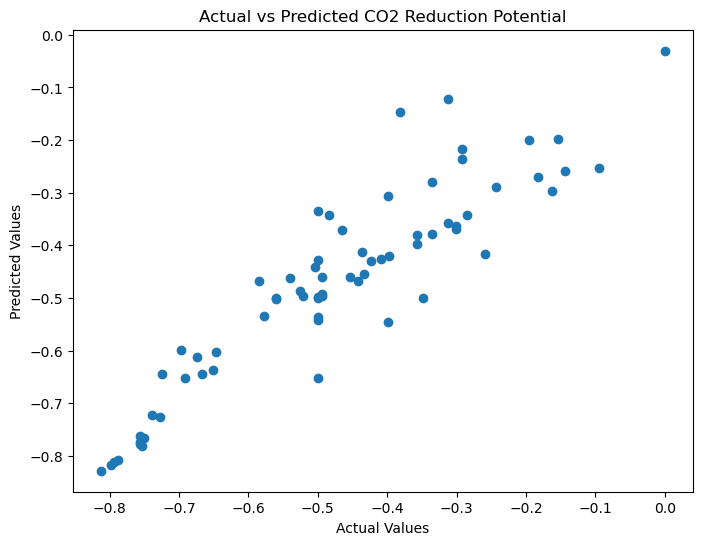

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title(
    "Actual vs Predicted CO2 Reduction Potential"
)
plt.show()

The predicted values closely follow the actual values, indicating that the Linear Regression model is capable of capturing the relationship between waste characteristics and CO₂ reduction potential.

## Residual Analysis
Residual analysis was performed to evaluate whether prediction errors are randomly distributed.

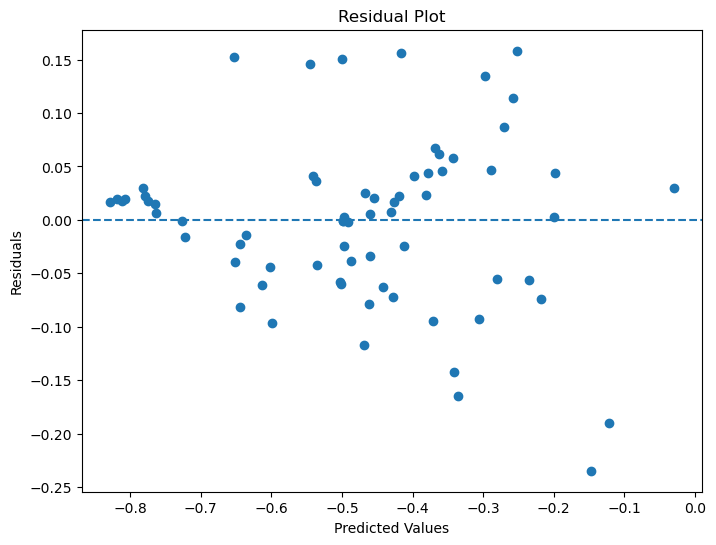

In [27]:
residuals = y_test - lr_pred

plt.figure(figsize=(8,6))

plt.scatter(
    lr_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title(
    "Residual Plot"
)

plt.show()

## Coefficient Analysis
The coefficients of the linear regression model were examined to understand the influence of different waste categories and waste management scenario on CO2 reduction potential.

In [28]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)
coef_df.head(15)

,Feature,Coefficient
59,scenario_Retrofit landfill,0.504342
55,scenario_Compost organics,0.380171
57,scenario_Digest organics,0.362343
54,scenario_Compost + retrofit,0.268786
56,scenario_Digest + retrofit,0.263476
58,scenario_Half waste,0.223784
32,countries_Netherlands,0.159930
46,countries_Uganda,0.130337
33,countries_Nigeria,0.127729
30,countries_Mexico,0.121540


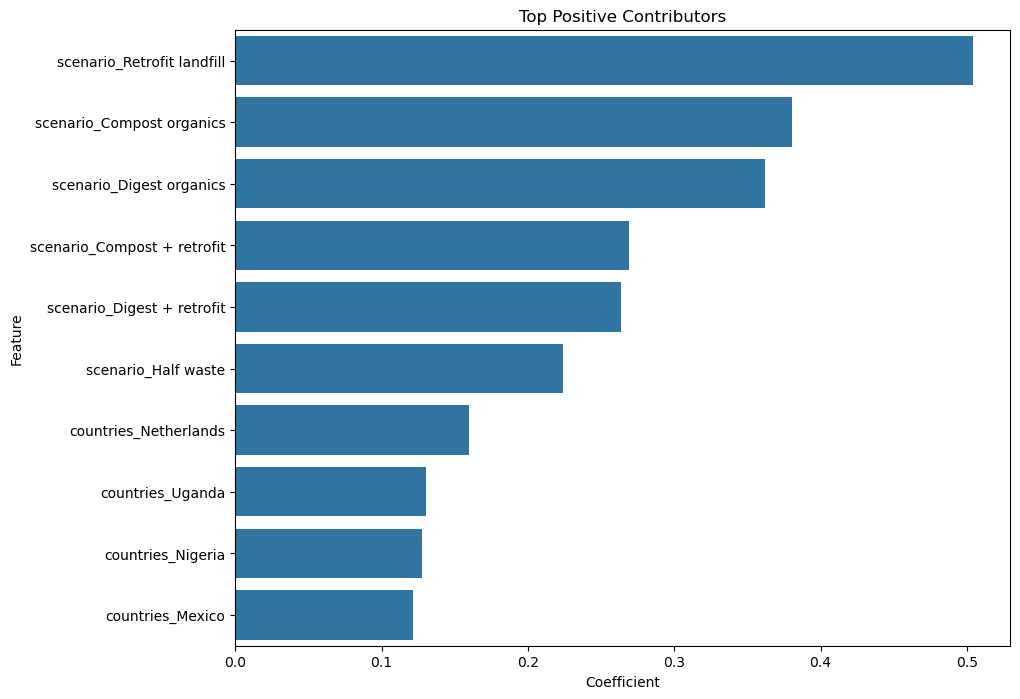

In [29]:
# Visualization
plt.figure(figsize=(10,8))

sns.barplot(
    data=coef_df.head(10),
    x="Coefficient",
    y="Feature"
)

plt.title(
    "Top Positive Contributors"
)

plt.show()

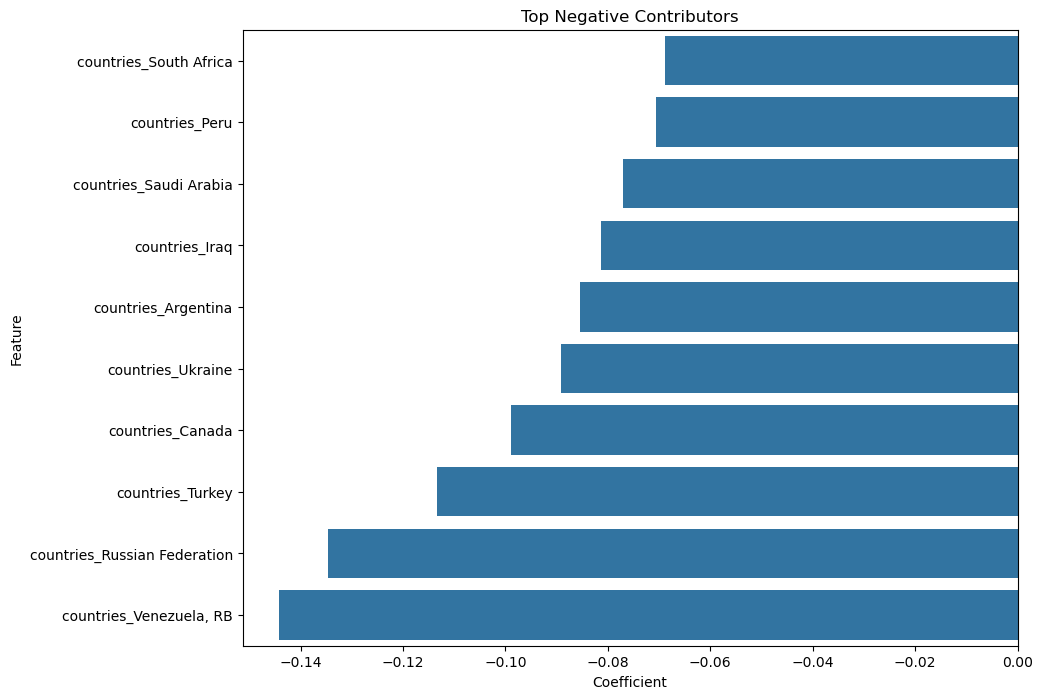

In [30]:
# Show Negative Contributors
plt.figure(figsize=(10,8))

sns.barplot(
    data=coef_df.tail(10),
    x="Coefficient",
    y="Feature"
)

plt.title(
    "Top Negative Contributors"
)

plt.show()

## Save the best model
The selected Linear regression model was saved for deployment in the Streamlit dashboard.

In [31]:
import pickle
pickle.dump(
    lr,
    open("C:/Projects/13_Waste_to_energy_Analytics_Platform/models/best_model.pkl","wb")
)
print("Save the model")

Save the model


## Save the model columns

In [33]:
import pickle

pickle.dump(
    X.columns.tolist(),
    open(
        "C:/Projects/13_Waste_to_energy_Analytics_Platform/models/model_columns.pkl",
        "wb"
    )
)

print("Model columns saved.")

Model columns saved.


# Conclusion

Three machine learning models were developed and evaluated:

1. Linear Regression
2. Random Forest Regressor
3. XGBoost Regressor

Linear Regression achieved the strongest predictive performance, with the highest R² score and lowest prediction errors.

Residual analysis indicated that the model provides a reasonable fit to the data, while coefficient analysis identified the most influential factors affecting CO₂ emissions reduction potential.

The final model was saved and will be integrated into the Streamlit dashboard for interactive sustainability analysis.